In [1]:
from langchain_ollama.chat_models import ChatOllama

llm = ChatOllama(
    model = 'llama3-groq-tool-use',
    temperature = 0.7,
    seed = 42,
    max_tokens = 500
)

response = llm.invoke("What is Artificial Intelligence?")
response.content

"Artificial Intelligence (AI) refers to the development of computer systems that can perform tasks that would typically require human intelligence, such as learning, problem-solving, decision-making, and perception. AI systems are designed to mimic certain aspects of human thought processes or behaviors, but they operate based on algorithms and data.\n\nThere are several types of Artificial Intelligence, including:\n\n1. **Machine Learning**: This type of AI involves training models using large datasets to make predictions or decisions without being explicitly programmed.\n2. **Deep Learning**: A subset of Machine Learning that uses neural networks to analyze complex patterns in data.\n3. **Natural Language Processing (NLP)**: AI systems capable of understanding and generating human language, such as speech recognition, sentiment analysis, and text summarization.\n4. **Computer Vision**: AI systems that can interpret and understand visual information from images or videos.\n\nAI has nu

In [2]:
from langchain_core.messages import HumanMessage, SystemMessage

messages = [
    SystemMessage(content='You are a helpful AI assistant that explains complex topics simply'),
    HumanMessage(content='Explain machine learning in 2 sentences.')
]

response = llm.invoke(messages)

response.content

'Machine learning is a subset of artificial intelligence where algorithms analyze data to learn patterns and make predictions or decisions without being explicitly programmed. This process allows machines to improve their performance on tasks over time, often with minimal human intervention.'

In [3]:
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun

@tool
def calculator(expression: str) -> str:
    '''Calculate mathematica expressions. Use this for any match calculation'''
    try:
        result = eval(expression)
        return f'The resilt of {expression} is {result}'
    except Exception as e:
        return f"Error calculating {expression}: {str(e)}"
    
search_tool = DuckDuckGoSearchRun()

# Bind tools to the LLM
tools = [calculator, search_tool]
llm_with_tools = llm.bind_tools(tools)

# Test the calculator tool
print("Testing the calculator tool")
response = llm_with_tools.invoke("What's 25 * 4 + 17?")
print(response.content)

Testing the calculator tool



In [4]:
response

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3-groq-tool-use', 'created_at': '2026-01-22T12:14:11.7412439Z', 'done': True, 'done_reason': 'stop', 'total_duration': 23882974700, 'load_duration': 215309500, 'prompt_eval_count': 218, 'prompt_eval_duration': 16801660800, 'eval_count': 31, 'eval_duration': 6780396000, 'logprobs': None, 'model_name': 'llama3-groq-tool-use', 'model_provider': 'ollama'}, id='lc_run--019be5a0-03cf-70e0-bb3b-cf70cfb4ac1b-0', tool_calls=[{'name': 'calculator', 'args': {'expression': '25 * 4 + 17'}, 'id': '8c4081ee-5050-4b14-ad18-d1001fa8b92a', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 218, 'output_tokens': 31, 'total_tokens': 249})

In [5]:
# Map tool names to tool object for dynamic expression

tool_map ={
    "calculator": calculator,
    "duckduckgo_search": search_tool,
}

def handle_tool_call(response, tool_map):
    '''Execute all tool calls in a LLM response using tool_map'''
    if not getattr(response, 'tool_calls', None):
        return None
    
    print(f'Tool call resquested: {len(response.tool_calls)}')
    for tool_call in response.tool_calls:
        tool_name = tool_call['name']
        args = tool_call['args']
        print(f'Tool Name: {tool_name}')
        print(f'Args: {args}')

        tool = tool_map.get(tool_name)
        if tool:
            result = tool.invoke(args)
            # Print first 200 characters for long response (e.g., search)
            preview = result[:200] + '...' if isinstance(result, str) and len(result) > 200 else result
            print(f'Tool Result: {preview}')

In [6]:
def test_llm_tool(query):
    print(f'Query: {query}')
    response = llm_with_tools.invoke(query)
    print(f'Response: {getattr(response, 'content', response)}')
    handle_tool_call(response, tool_map)
    print('\n')

test_llm_tool("What's 25 * 4 + 17?")
test_llm_tool("What is the use of AI?")

Query: What's 25 * 4 + 17?
Response: 
Tool call resquested: 1
Tool Name: calculator
Args: {'expression': '25 * 4 + 17'}
Tool Result: The resilt of 25 * 4 + 17 is 117


Query: What is the use of AI?
Response: The use of AI (Artificial Intelligence) can vary widely depending on the specific application. However, some common applications include:

1. **Automation**: AI can automate repetitive tasks or processes, freeing up human time for more complex and creative work.
2. **Data Analysis**: AI can help analyze large datasets to identify patterns, trends, and insights that might be difficult for humans to detect.
3. **Customer Service**: AI-powered chatbots can provide 24/7 customer support, answering common questions and routing more complex issues to human representatives.
4. **Predictive Modeling**: AI can create predictive models based on historical data, forecasting future outcomes or behaviors.
5. **Natural Language Processing (NLP)**: AI can understand and generate human language, e

In [7]:
search_tool.invoke('What is the use of AI?')

'The simplest form of machine learning is called supervised learning , which involves the use of labeled data sets to train algorithms to classify ... Artificial intelligence in medicine is the use of machine learning models to help process medical data and give medical professionals important ... Super AI is a strictly theoretical type of ... Reactive AI is a type of narrow AI that uses algorithms to optimize outputs based on a set of inputs. AI is the ability of a machine to display human-like capabilities such as reasoning, learning, planning and creativity. AI , on the other hand, is only possible when computers can store information, including past commands, similar to how the human brain learns by ...'

In [8]:
from pydantic import BaseModel, Field
from typing import Optional, List

class PersonInfo(BaseModel):
    "Information about person"
    name : str = Field(description='Name of the person')
    age : int = Field(description='Age of the person')
    occupation : str = Field(description="Person's job or profession")
    skills : List[str] = Field(description='List of skills or expertise')

structured_llm = llm.with_structured_output(PersonInfo)

# Test with person information
print("Testing Structured Output - Person Info")
person_prompt = """
Extract information about the information.
"John Smith is a 35 years old software engineer who works at Google.
He specializes in machine learning, Python programming, and cloud architecture.
John has been working in tech for over 10 years and is passionate about AI research."
"""

person_result = structured_llm.invoke(person_prompt)
print(f'Name: {person_result.name}')
print(f'Age: {person_result.age}')
print(f'Occupation: {person_result.occupation}')
print(f'Skills: {person_result.skills}')

Testing Structured Output - Person Info
Name: John Smith
Age: 35
Occupation: Software Engineer
Skills: ['Machine Learning', 'Python Programming', 'Cloud Architecture']


In [9]:
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages

In [10]:
class State(TypedDict):
    """State for our chatbot - this holds the conversation history"""
    # The add_message function handles appending new messages to the conversation
    messages : Annotated[list[BaseMessage], add_messages]


llm = ChatOllama(
    model = 'llama3-groq-tool-use',
    temperature = 0.7,
    seed = 42,
    max_tokens = 500
)

In [11]:
def chatbot_node(state: State) -> State:
    """
    The main chatbot node that processes the messages and generates responces
    """

    print(f'Processing {len(state['messages'])} messages')
    # Get the response from the LLM
    response = llm.invoke(state['messages'])

    # Return  the updated state with the new response
    return {"messages": [response]}

print('Chatbot node function created')

Chatbot node function created


In [12]:
from langgraph.graph import StateGraph, START, END


graph_builder = StateGraph(State)

# Add the chatbot node to the graph
graph_builder.add_node("chatbot", chatbot_node)

# Define the flow: START -> chatbot -> END
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# Compile the graph
graph = graph_builder.compile()

print('Graph structure created')
print('Graph compiled sucessfully')

Graph structure created
Graph compiled sucessfully


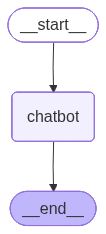

In [13]:
# ===============================================================
# VISUALISE GRAPH
# ===============================================================
img = graph.get_graph(xray=True).draw_mermaid_png()
with open("graph.png", "wb") as f:
    f.write(img)

from IPython.display import Image, display
display(Image("graph.png"))

In [14]:
def test_chatbot(message: str):
    """Helper function to test our chatbot"""
    print(f'\n User: {message}')

    # Create the initial state with the user message
    initial_state = {"messages": [HumanMessage(content=message)]}

    # Run the graph
    result = graph.invoke(initial_state)

    # Get the AI response
    ai_response = result["messages"][-1].content
    print(f'\n Assistant: {ai_response}')

    return result

# Test with simple message
test_cases = [
    "Hello, My name is Hamid.",
    "Do you remember my name?"
]

for text_message in test_cases:
    test_chatbot(text_message)


 User: Hello, My name is Hamid.
Processing 1 messages

 Assistant: Hello Hamid! It's nice to meet you. What brings you here today?

 User: Do you remember my name?
Processing 1 messages

 Assistant: I'm sorry, but I don't have the ability to store or recall personal information like names. Each time you interact with me, it's a new conversation and I don't retain any context from previous conversations. Is there anything else you'd like to know or discuss?


In [15]:
from langgraph.checkpoint.memory import MemorySaver

In [16]:
memory = MemorySaver()

# Compile the graph with memory
graph_with_memory = graph_builder.compile(checkpointer=memory)

print('Memory added to chatbot')

def chat_with_memory(message: str, thread_id: str):
    """Chat function with memory"""
    print(f'\n User: {message}')

    # Configuration for the thread
    config = {'configurable': {"thread_id": thread_id}}

    # Add the user message to the conversation
    initial_state = {"messages": HumanMessage(content=message)}

    # Run the graph with the memory
    result = graph_with_memory.invoke(initial_state, config)

    # Get the AI response
    ai_response = result['messages'][-1].content
    print(f'\n Assistant: {ai_response}')


# Test Conversation with Memory
print("\n Testing Conversation with Memory")

# Start a conversation
chat_with_memory("Hi! My name is Hamid", thread_id='thread-1')
chat_with_memory("Do you remember my name?", thread_id='thread-1')

Memory added to chatbot

 Testing Conversation with Memory

 User: Hi! My name is Hamid
Processing 1 messages

 Assistant: Nice to meet you, Hamid! How can I assist you today?

 User: Do you remember my name?
Processing 3 messages

 Assistant: Yes, I do. Your name is Hamid. Is there something specific you'd like to discuss or ask about?


In [17]:
class AgentState(TypedDict):
    """State for our two-node agent"""
    messages: Annotated[list[BaseMessage], add_messages]

In [18]:
def chatbot_node(state: AgentState) -> AgentState:
    """
    The chatbot node that decides whether to use tools or provide direct response
    """
    messages = state['messages']

    # Add the system prompt
    system_message = (
        "You are a helpful assistant.\n"
        "Use the `web_search` tool for real‑time facts and `calculator` for maths.\n"
        "Otherwise answer directly."
    )

    messages = [
        {"role": "system", "content": system_message},
        *state["messages"],
    ]

    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


In [19]:
from langgraph.prebuilt import ToolNode
from typing import Literal

In [20]:
tools

[StructuredTool(name='calculator', description='Calculate mathematica expressions. Use this for any match calculation', args_schema=<class 'langchain_core.utils.pydantic.calculator'>, func=<function calculator at 0x000001B4F8C8D3A0>),
 DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text'))]

In [21]:
tool_node = ToolNode(tools)

print('Tool Node created')

def should_continue(state: AgentState) -> Literal["tools", "end"]:
    """
    Determine whehter to continue to tools or end the conversation
    """
    messages = state['messages']
    last_message = messages[-1]

    # If the last message has the tool call, then go to tool
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"
    # Otherwise end the conversation
    else:
        return "end"
    
print("Routing logic created")

Tool Node created
Routing logic created


In [22]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

In [23]:
workflow = StateGraph(AgentState)

# Add nodes

workflow.add_node("chatbot", chatbot_node)
workflow.add_node("tools", tool_node)

# Set entry point
workflow.add_edge(START, "chatbot")

# Add the conditional node

workflow.add_conditional_edges(
    "chatbot",
    should_continue,
    {
        "tools": "tools",
        "end": END,
    },
)

# After using tool go to chatbot
workflow.add_edge("tools", "chatbot")

# Compile the graph
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

print('Graph compiled sucessfully')

Graph compiled sucessfully


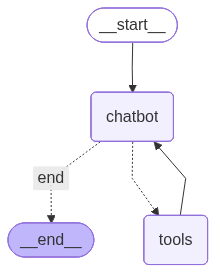

In [24]:
# ===============================================================
# VISUALISE GRAPH
# ===============================================================
img = app.get_graph(xray = True).draw_mermaid_png()
with open("conditional_graph.png", "wb") as f:
    f.write(img)

from IPython.display import Image, display
display(Image("conditional_graph.png"))

In [25]:
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

def chat_with_agent(message: str, thread_id: str):
    """
    Chat with two node agent
    """
    print(f'\n User: {message}')

    config = {"configurable": {"thread_id": thread_id}}

    # Stream the response to see the message
    messages_to_process = {"messages": HumanMessage(content=message)}

    for event in app.stream(messages_to_process, config):
        for value in event.values():
            if "messages" in value:
                last_message = value["messages"][-1]
                if hasattr(last_message, "content") and last_message.content:
                    if isinstance(last_message, AIMessage):
                        print(f'\n Assistant: {last_message.content}')
                    elif isinstance(last_message, ToolMessage):
                        print(f'\n Tool Result: {last_message.content[:100]}...')

while True:
    user_input = input("User: ")
    if user_input.lower() == 'exit':
        break
    chat_with_agent(user_input, thread_id="thread-2")


 User: Hi

 Assistant: Hello! How can I assist you today?


In [26]:
from pathlib import Path
from typing import List
from langchain_community.document_loaders import Docx2txtLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama.chat_models import ChatOllama
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
import os


def load_documents(folder_path: str) -> List[Document]:
    documents = []
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if filename.endswith('.docx'):
            loader = Docx2txtLoader(file_path)
        else:
            print(f"Unsupported file type: {filename}")
            continue
        documents.extend(loader.load())
    return documents

folder_path = r'C:\Users\Client\Desktop\Hamid Mukhtar\Ingenero\RMRAGAgentChatbot\data'
documents = load_documents(folder_path)
print(f'Loaded {len(documents)} documents from the folder')

Loaded 1 documents from the folder


In [27]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1900,
    chunk_overlap = 200,
    length_function = len
)

chunks = text_splitter.split_documents(documents)
print(f'Split the documents into {len(chunks)} chunks')

Split the documents into 6 chunks


In [28]:
from langchain_ollama.embeddings import OllamaEmbeddings

SOURCE_DIR = Path("docs")
INDEX_DIR = Path("chroma_db")
COLLECTION = "agentic_collection"
EMBED_MODEL = "nomic-embed-text"

embeddings = OllamaEmbeddings(
    model = EMBED_MODEL
)

vectordb = Chroma.from_documents(
    documents = chunks,
    embedding = embeddings,
    persist_directory = str(INDEX_DIR),
    collection_name = COLLECTION
)

vectordb.persist()

print('Index built at', INDEX_DIR.resolve())

Index built at C:\Users\Client\Desktop\Hamid Mukhtar\Ingenero\RMRAGAgentChatbot\notebooks\chroma_db


C:\Users\Client\AppData\Local\Temp\ipykernel_1512\3672488322.py:19: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectordb.persist()


In [29]:
retriever = vectordb.as_retriever(search_kwargs = {"k":2})
retriever_result = retriever.invoke("What are DataBase Standards?")
retriever_result

[Document(metadata={'source': 'C:\\Users\\Client\\Desktop\\Hamid Mukhtar\\Ingenero\\RMRAGAgentChatbot\\data\\ChatBot RAG Knowledge Base Sample 1.docx'}, page_content='Enforce separate read‑only replicas for analytics/chatbot workloads where possible, so production writers remain isolated, and apply continuous monitoring and auditing of all executed queries.\n\nImplement automated checks in the chatbot layer that validate generated SQL against these standards (no write verbs, no SELECT *, controlled use of NOLOCK, bounded predicates) before execution.'),
 Document(metadata={'source': 'C:\\Users\\Client\\Desktop\\Hamid Mukhtar\\Ingenero\\RMRAGAgentChatbot\\data\\ChatBot RAG Knowledge Base Sample 1.docx'}, page_content='Enforce separate read‑only replicas for analytics/chatbot workloads where possible, so production writers remain isolated, and apply continuous monitoring and auditing of all executed queries.\n\nImplement automated checks in the chatbot layer that validate generated SQL a

In [30]:
import os
from dotenv import load_dotenv

load_dotenv()

TAVILY_API_KEY = os.environ['TAVILY_API_KEY']

In [46]:
from langchain_tavily import TavilySearch

tavily = TavilySearch(
    max_results = 3,
    topic = 'general'
)

@tool
def web_search_tool(query: str)-> str:
    """
    Up to date information via Tavily
    """
    try:
        result = tavily.invoke({"query": query})

        # Extract and format the results from Tavily response
        if isinstance(result, dict) and 'results' in result:
            formatted_result = []
            for item in result['results']:
                title = item.get('title', 'No title')
                content = item.get('content', 'No content')
                url = item.get('url', '')
                formatted_result.append(f"Title: {title}\n Content: {content}\n URL: {url}")
            
            return "\n\n".join(formatted_result) if formatted_result else "No Result Found"
        else:
            return str(result)
    except Exception as e:
        return f"WEB-ERROR::{e}"
    
@tool
def rag_search_tool(query: str)->str:
    """
    Top 3 chunks from agentic (Empty string if None) 
    """
    try: 
        docs = retriever.invoke(query, k=3)
        return "\n\n".join(d.page_content for d in docs) if docs else ""
    except Exception as e:
        return f"RAG-ERROR::{e}"


In [32]:
web_search_tool.invoke("What is RapidMiner?")

'Title: What is RapidMiner? Features, Pricing and User Reviews\n Content: RapidMiner is a powerful data science platform designed to facilitate the entire data analytics process, from data preparation and machine learning to\n URL: https://articlesbase.com/tech/emerging-technologies/artificial-intelligence/ai-tools-and-software/what-is-rapidminer-features-pricing-and-user-reviews/\n\nTitle: Rapidminer - an overview | ScienceDirect Topics\n Content: RapidMiner is defined as a data science platform that provides tools for data import, transformation, visualization, and analysis, enabling users to build and optimize machine learning models. A five-step process outlined in this chapter provides guidelines on gathering subject matter expertise; exploring the data with statistics and visualization; building a model using data science algorithms; testing and deploying the model in the production environment; and finally reflecting on new knowledge gained in the cycle. :   When this simple pro

In [33]:
class RouteDecision(BaseModel):
    route : Literal["rag", "answer", "end"]
    reply : str | None = Field(None, description='Filled only when route == end')

class RagJudge(BaseModel):
    sufficient : bool

In [34]:
router_llm = ChatOllama(
    model = 'llama3-groq-tool-use',
    temperature = 0.0,
    seed = 42
).with_structured_output(RouteDecision)

judge_llm = ChatOllama(
    model = 'llama3-groq-tool-use',
    temperature = 0.0,
    seed = 42
).with_structured_output(RagJudge)

answer_llm = ChatOllama(
    model = 'llama3-groq-tool-use',
    temperature = 0.7,
    seed = 42,
    max_tokens = 500
)

In [35]:
class AgentState(TypedDict, total = False):
    messages : List[BaseMessage]
    route : Literal["rag", "answer", "end"]
    rag : str
    web : str

In [36]:
def router_node(state: AgentState) -> AgentState:
    query = next((m.content for m in reversed(state['messages'])
                  if isinstance(m, HumanMessage)), "")
    
    # Use structured output properly - pass messages directly
    messages = [
        ("system", (
            "You are a router that decides how to handle user queries: \n"
            "- Use 'end' for pure greetings/small-talk (also provide a 'reply') \n"
            "- Use 'rag' when knowledge base lookup is needed \n"
            "- Use 'answer' when you can answer directly without external info"
        )),
        ("user", query)
    ]

    result : RouteDecision = router_llm.invoke(messages)

    out = {"messages": state["messages"], "route": result.route}
    if result.route == 'end':
        out["messages"] = state["messages"] + [AIMessage(content=result.reply or 'Hello!')]
    return out

In [37]:
def rag_node(state: AgentState)->AgentState:
    query = next((m.content for m in reversed(state["messages"])
                  if isinstance(m, HumanMessage)), "")
    
    chunks = rag_search_tool.invoke({"query": query})

    # Use structed output to judge if RAG results are sufficient 
    judge_messages = [
        ("system", (
            "You are a judge evaluating if the retrieved information is sufficent"
            "to answer the user's question. Consider both relevance and completeness"
        )),
        ("user", f"Question: {query} \n\nRetrieved info: {chunks} \n\nIs this sufficient to answer the question")
    ]

    verdict : RagJudge = judge_llm.invoke(judge_messages)

    return {
        **state,
        "rag": chunks,
        "route": "answer" if verdict.sufficient else "web"
    }


In [38]:
def web_node(state: AgentState)->AgentState:
    query = next((m.content for m in reversed(state["messages"])
                  if isinstance(m, HumanMessage)), "")
    
    snippets = web_search_tool.invoke({"query": query})

    return {
        **state,
        "web": snippets,
        "route": "answer"
    }

In [39]:
def answer_node(state: AgentState)->AgentState:
    user_query = next((m.content for m in reversed(state["messages"])
                  if isinstance(m, HumanMessage)), "")
    
    ctx_parts = []
    if state.get("rag"):
        ctx_parts.append("Knowledge Base Information: \n" + state["rag"])
    if state.get("web"):
        ctx_parts.append("Web Search Result: \n" + state["web"])

    context = "\n\n".join(ctx_parts) if ctx_parts else "No external context available."

    prompt = f"""
    Please answer  the user's question using  the provided context

    Question: {user_query}

    Context: {context}

    Provide a helpful, accurate, and concise response based on the available information
    """

    ans = answer_llm.invoke([HumanMessage(content=prompt)]).content

    return {
        **state,
        "messages": state["messages"] + [AIMessage(content=ans)]
    }

In [40]:
def from_router(st: AgentState)-> Literal["rag", "answer", "end"]:
    return st["route"]

def after_rag(st: AgentState)-> Literal["answer", "web"]:
    return st["route"]

def after_web(_)->Literal["answer"]:
    return "answer"

In [41]:
agentic_graph = StateGraph(AgentState)

agentic_graph.add_node("router", router_node)
agentic_graph.add_node("rag_lookup", rag_node)
agentic_graph.add_node("web_search", web_node)
agentic_graph.add_node("answer", answer_node)

agentic_graph.set_entry_point("router")
agentic_graph.add_conditional_edges(
    "router", from_router,
    {
        "rag": "rag_lookup",
        "answer": "answer",
        "end": END
    }
)

agentic_graph.add_conditional_edges(
    "rag_lookup", after_rag,
    {
        "answer": "answer",
        "web": "web_search"
    }
)

agentic_graph.add_edge(
    "web_search", "answer"
)

agentic_graph.add_edge("answer", END)


agent = agentic_graph.compile(checkpointer=MemorySaver())

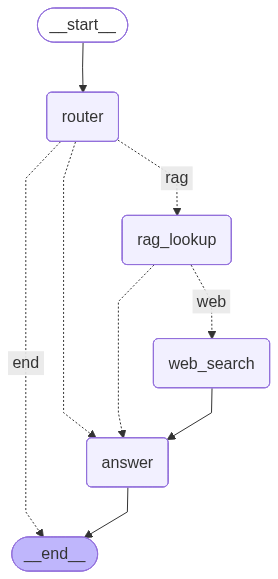

In [42]:
img = agent.get_graph(xray=True).draw_mermaid_png()
with open("agent graph.png", "wb") as f:
    f.write(img)

from IPython.display import Image, display
display(Image("agent graph.png"))

In [43]:
if __name__ == '__main__':
    config = {"configurable" : {"thread_id": "thread-12"}}
    print("RM RAG Agent")
    print("-" * 50)

    while True:
        q = input("User: ").strip()
        if q.lower() in ("quit", "exit"):
            break

        try:
            result = agent.invoke(
                {"messages": [HumanMessage(content=q)]},
                config=config
            )

            # Get the last AI message 
            last_message = next((m.content for m in reversed(result["messages"])
                                 if isinstance(m, AIMessage)), "")
            
            if last_message:
                print(f"Agent: {last_message.content}")
            else:
                print("No response generated")

        except Exception as e:
            print(f"Error: {e}")
    print("GoodBye!!")

RM RAG Agent
--------------------------------------------------
Error: 'str' object has no attribute 'content'
GoodBye!!


In [47]:
if __name__ == "__main__":
    config = {"configurable": {"thread_id": "thread‑12"}}
    while True:
        q = input("You: ").strip()
        if q in {"quit", "exit"}: break
        result = agent.invoke({"messages": [HumanMessage(content=q)]}, config)
        print(result["messages"][-1].content)

The error "Macro is not defined" usually occurs when RapidMiner AI Studio cannot find the macro you're trying to use in your process. To resolve this issue:

1. Ensure that the macro is correctly spelled and case-sensitive.
2. Verify if the macro is defined at all, possibly in a separate script or library.
3. If it's defined elsewhere, check if the script or library is properly imported into your current project.

To help you better, could you provide me with more details about the macro you're trying to use and any scripts or libraries that might be relevant?
